In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/2025-sep-dl-gen-ai-project/sample_submission.csv
/kaggle/input/2025-sep-dl-gen-ai-project/train.csv
/kaggle/input/2025-sep-dl-gen-ai-project/test.csv


## Installs & imports

In [2]:
!pip install -q transformers wandb kagglehub

import os
import time
import datetime
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, DataCollatorWithPadding


2025-11-29 23:28:07.407082: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764458887.591054      38 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764458887.646285      38 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


## Config

In [3]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()

USERNAME = user_secrets.get_secret("KAGGLE_USERNAME")
AUTO_GENERATE_REPO = True 
OUT_DIR = Path("/kaggle/working/project_outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

##wb setup
WANDB_KEY = user_secrets.get_secret("WANDB_API_KEY")
USE_WANDB = False
try:
    import wandb
    if WANDB_KEY:
        wandb.login(key=WANDB_KEY)
        USE_WANDB = True
        print("W&B: logged in (live mode).")
    else:
        # run offline to avoid wandb errors when no key present
        os.environ["WANDB_MODE"] = "offline"
        USE_WANDB = True
        print("W&B: running in offline mode (no WANDB_API_KEY set).")
except Exception as e:
    print("W&B not available:", e)
    USE_WANDB = False


Device: cuda


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: 23f1000805 (23f1000805-indian-institute-of-technology-madras) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


W&B: logged in (live mode).


## Load data

In [4]:
DATA_DIR = Path("/kaggle/input/2025-sep-dl-gen-ai-project")
train_df = pd.read_csv(DATA_DIR / "train.csv")
test_df = pd.read_csv(DATA_DIR / "test.csv")
sample_sub = pd.read_csv(DATA_DIR / "sample_submission.csv")

EMOTION_LABELS = ["anger", "fear", "joy", "sadness", "surprise"]
print("Loaded data:", len(train_df), "train rows,", len(test_df), "test rows")

Loaded data: 6827 train rows, 1707 test rows


## Train / val split

In [5]:
train_df, val_df = train_test_split(train_df, test_size=0.2, random_state=42)
y_train = train_df[EMOTION_LABELS].values
y_val = val_df[EMOTION_LABELS].values
print("Split sizes:", len(train_df), len(val_df))

Split sizes: 5461 1366


##  SCRATCH MODEL (bilstm)

In [8]:
#Build small vocab from training texts
from collections import Counter
def build_vocab(texts, max_words=20000):
    c = Counter()
    for t in texts:
        c.update(t.lower().split())
    vocab = {"<pad>":0, "<unk>":1}
    for i, (w, _) in enumerate(c.most_common(max_words)):
        vocab[w] = i + 2
    return vocab

vocab = build_vocab(train_df["text"].tolist(), max_words=10000)
vocab_size = len(vocab)
print("Vocab size (scratch):", vocab_size)

#encode function
def encode_text(text, vocab, max_len=50):
    words = text.lower().split()
    ids = [vocab.get(w, vocab["<unk>"]) for w in words]
    if len(ids) < max_len:
        ids += [vocab["<pad>"]] * (max_len - len(ids))
    else:
        ids = ids[:max_len]
    return ids

#Dataset and dataloader
class SimpleDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len=50):
        self.texts = texts
        self.labels = labels
        self.vocab = vocab
        self.max_len = max_len
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, idx):
        x = encode_text(self.texts[idx], self.vocab, self.max_len)
        y = self.labels[idx] if self.labels is not None else np.zeros(len(EMOTION_LABELS), dtype=int)
        return torch.tensor(x, dtype=torch.long), torch.tensor(y, dtype=torch.float32)

MAXLEN_SCRATCH = 50
train_ds_s = SimpleDataset(train_df["text"].tolist(), y_train, vocab, MAXLEN_SCRATCH)
val_ds_s = SimpleDataset(val_df["text"].tolist(), y_val, vocab, MAXLEN_SCRATCH)
test_ds_s = SimpleDataset(test_df["text"].tolist(), np.zeros((len(test_df), len(EMOTION_LABELS))), vocab, MAXLEN_SCRATCH)

train_loader_s = DataLoader(train_ds_s, batch_size=64, shuffle=True)
val_loader_s = DataLoader(val_ds_s, batch_size=128, shuffle=False)
test_loader_s = DataLoader(test_ds_s, batch_size=128, shuffle=False)

#Simple BiLSTM model
class SimpleBiLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128, num_labels=5, pad_idx=0):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_dim*2, num_labels)
    def forward(self, x):
        x = self.embed(x)
        out, _ = self.lstm(x)
        pooled = out.mean(dim=1)
        return self.fc(pooled)

model_scratch = SimpleBiLSTM(vocab_size=vocab_size, embed_dim=128, hidden_dim=128, num_labels=len(EMOTION_LABELS), pad_idx=vocab["<pad>"])
model_scratch = model_scratch.to(DEVICE)

opt = torch.optim.AdamW(model_scratch.parameters(), lr=3e-4)
criterion = nn.BCEWithLogitsLoss()

#W&B run for scratch
if USE_WANDB:
    wandb.init(project="23f1000805-t32025", name="scratch-bilstm", reinit=True)

#training loop
EPOCHS_SCRATCH = 100
best_val_f1_s = 0.0
scratch_out_dir = OUT_DIR / "scratch_model"
scratch_out_dir.mkdir(parents=True, exist_ok=True)

for ep in range(1, EPOCHS_SCRATCH + 1):
    model_scratch.train()
    total_loss = 0.0
    steps = 0
    for xb, yb in train_loader_s:
        xb = xb.to(DEVICE); yb = yb.to(DEVICE)
        opt.zero_grad()
        logits = model_scratch(xb)
        loss = criterion(logits, yb)
        loss.backward()
        opt.step()
        total_loss += float(loss.detach().cpu().numpy())
        steps += 1
    train_loss = total_loss / max(1, steps)

    # validation
    model_scratch.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for xb, yb in val_loader_s:
            xb = xb.to(DEVICE)
            logits = model_scratch(xb)
            probs = torch.sigmoid(logits).cpu().numpy()
            preds = (probs > 0.5).astype(int)
            all_preds.append(preds)
            all_labels.append(yb.numpy())
    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)
    val_f1 = f1_score(all_labels, all_preds, average="micro", zero_division=0)

    if USE_WANDB:
        wandb.log({"scratch/train_loss": train_loss, "scratch/val_f1_micro": val_f1, "epoch": ep})

    print(f"[Scratch] Epoch {ep}/{EPOCHS_SCRATCH} train_loss={train_loss:.4f} val_f1_micro={val_f1:.4f}")

    if val_f1 > best_val_f1_s:
        best_val_f1_s = val_f1
        torch.save(model_scratch.state_dict(), scratch_out_dir / "best_scratch_state.pt")
        # also save full model for convenience
        torch.save(model_scratch, scratch_out_dir / "best_scratch_full.pt")

if USE_WANDB:
    wandb.finish()

# test predictions scratch
model_scratch.eval()
test_preds_s = []
with torch.no_grad():
    for xb, _ in test_loader_s:
        xb = xb.to(DEVICE)
        logits = model_scratch(xb)
        probs = torch.sigmoid(logits).cpu().numpy()
        preds = (probs > 0.5).astype(int)
        test_preds_s.append(preds)
test_preds_s = np.vstack(test_preds_s)

sub_s = pd.DataFrame(test_preds_s, columns=EMOTION_LABELS)
sub_s.insert(0, "id", test_df["id"])
sub_path_s = OUT_DIR / "submission_scratch.csv"
sub_s.to_csv(sub_path_s, index=False)
print("Saved scratch submission:", sub_path_s)


Vocab size (scratch): 10002


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


[Scratch] Epoch 1/100 train_loss=0.6102 val_f1_micro=0.4426
[Scratch] Epoch 2/100 train_loss=0.5620 val_f1_micro=0.4426
[Scratch] Epoch 3/100 train_loss=0.5529 val_f1_micro=0.4485
[Scratch] Epoch 4/100 train_loss=0.5446 val_f1_micro=0.5004
[Scratch] Epoch 5/100 train_loss=0.5437 val_f1_micro=0.4599
[Scratch] Epoch 6/100 train_loss=0.5335 val_f1_micro=0.4559
[Scratch] Epoch 7/100 train_loss=0.5208 val_f1_micro=0.5221
[Scratch] Epoch 8/100 train_loss=0.5061 val_f1_micro=0.4559
[Scratch] Epoch 9/100 train_loss=0.4905 val_f1_micro=0.4196
[Scratch] Epoch 10/100 train_loss=0.4729 val_f1_micro=0.4921
[Scratch] Epoch 11/100 train_loss=0.4543 val_f1_micro=0.5294
[Scratch] Epoch 12/100 train_loss=0.4379 val_f1_micro=0.4577
[Scratch] Epoch 13/100 train_loss=0.4256 val_f1_micro=0.4849
[Scratch] Epoch 14/100 train_loss=0.4052 val_f1_micro=0.5199
[Scratch] Epoch 15/100 train_loss=0.3912 val_f1_micro=0.5362
[Scratch] Epoch 16/100 train_loss=0.3743 val_f1_micro=0.5246
[Scratch] Epoch 17/100 train_loss

epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇███
scratch/train_loss,███▇▇▆▆▅▅▅▄▄▄▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▂▁▁▁▁▁▁▁▁▁▁
scratch/val_f1_micro,▁▁▂▁▁▃▂▃▃▄▅▅▅▆▆▆▆▆▇▆▇▇▇▇▇▇▇▇▇█▇▇████▇███
epoch,100
scratch/train_loss,0.03263
scratch/val_f1_micro,0.69968


Saved scratch submission: /kaggle/working/project_outputs/submission_scratch.csv


## Transformer Models helper (BERT and RoBERTa)

In [9]:
def train_transformer(model_name, train_texts, train_labels, val_texts, val_labels, test_texts, model_tag):
    print("\nTraining:", model_name)
    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
    MAXLEN = 128
    train_enc = tokenizer(list(train_texts), padding="max_length", truncation=True, max_length=MAXLEN)
    val_enc = tokenizer(list(val_texts), padding="max_length", truncation=True, max_length=MAXLEN)
    test_enc = tokenizer(list(test_texts), padding="max_length", truncation=True, max_length=MAXLEN)

    # simple dataset wrappers
    class HFDS(Dataset):
        def __init__(self, enc, labels=None):
            self.enc = enc
            self.labels = labels
        def __len__(self):
            return len(self.enc["input_ids"])
        def __getitem__(self, idx):
            item = {k: torch.tensor(v[idx]) for k,v in self.enc.items()}
            if self.labels is not None:
                item["labels"] = torch.tensor(self.labels[idx], dtype=torch.float)
            return item

    train_ds = HFDS(train_enc, train_labels)
    val_ds = HFDS(val_enc, val_labels)
    test_ds = HFDS(test_enc, np.zeros((len(test_texts), len(EMOTION_LABELS))))

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=len(EMOTION_LABELS),
        problem_type="multi_label_classification"
    )
    model.to(DEVICE)

    args = TrainingArguments(
        output_dir=str(OUT_DIR / f"{model_tag}_tmp"),
        num_train_epochs=8,
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        warmup_ratio=0.1,
        weight_decay=0.02,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1_micro",
        greater_is_better=True,
        save_total_limit=1,
        fp16=torch.cuda.is_available(),
        logging_steps=100,
        report_to="wandb" if USE_WANDB else None
    )

    data_collator = DataCollatorWithPadding(tokenizer, padding="max_length")

    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        probs = torch.sigmoid(torch.tensor(logits)).numpy()
        preds = (probs > 0.5).astype(int)
        return {"f1_micro": f1_score(labels, preds, average="micro", zero_division=0),
                "f1_macro": f1_score(labels, preds, average="macro", zero_division=0)}

    if USE_WANDB:
        wandb.init(project="23f1000805-t32025", name=model_tag, reinit=True)

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        tokenizer=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics
    )

    trainer.train()

    val_out = trainer.predict(val_ds, metric_key_prefix="eval")
    val_metrics = compute_metrics((val_out.predictions, val_out.label_ids))
    print("Validation metrics:", val_metrics)

    test_out = trainer.predict(test_ds)
    test_logits = test_out.predictions
    test_probs = torch.sigmoid(torch.tensor(test_logits)).numpy()
    test_bin = (test_probs > 0.5).astype(int)
    sub = pd.DataFrame(test_bin, columns=EMOTION_LABELS)
    sub.insert(0, "id", test_df["id"])
    sub_path = OUT_DIR / f"submission_{model_tag}.csv"
    sub.to_csv(sub_path, index=False)
    print("Saved submission:", sub_path)

    # save HF model and tokenizer
    saved_folder = OUT_DIR / f"{model_tag}_hf"
    trainer.save_model(str(saved_folder))
    tokenizer.save_pretrained(str(saved_folder))
    # also save state dict
    torch.save(model.state_dict(), OUT_DIR / f"{model_tag}_state.pt")
    print("Saved model to:", saved_folder)

    if USE_WANDB:
        try:
            wandb.log({"val_f1_micro": val_metrics["f1_micro"], "val_f1_macro": val_metrics["f1_macro"]})
            wandb.finish()
        except Exception:
            pass

    # cleanup trainer tmp to save disk
    try:
        shutil.rmtree(str(OUT_DIR / f"{model_tag}_tmp"), ignore_errors=True)
    except Exception:
        pass

    return {"model_tag": model_tag, "val_metrics": val_metrics, "submission": str(sub_path), "hf_folder": str(saved_folder)}


## Train BERT (bert-base-uncased)

In [10]:
res_bert = train_transformer("bert-base-uncased", train_df["text"].tolist(), y_train, val_df["text"].tolist(), y_val, test_df["text"].tolist(), model_tag="bert_base_uncased")


Training: bert-base-uncased


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

...

/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked t

Validation metrics: {'f1_micro': 0.8545632015617375, 'f1_macro': 0.8371030030449887}


/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Saved submission: /kaggle/working/project_outputs/submission_bert_base_uncased.csv
Saved model to: /kaggle/working/project_outputs/bert_base_uncased_hf


eval/f1_macro,▁▅▆▇█████
eval/f1_micro,▁▅▆▇█████
eval/loss,█▄▂▁▁▁▁▁▁
eval/runtime,█▆▃▃▂▁▃▂▆
eval/samples_per_second,▁▃▆▆▇█▆▇▃
eval/steps_per_second,▁▃▆▆▇█▆▇▃
test/f1_macro,▁
test/f1_micro,▁
test/loss,▁
test/runtime,▁
test/samples_per_second,▁


## Train RoBERTa (roberta-base)

In [11]:
res_roberta = train_transformer("roberta-base", train_df["text"].tolist(), y_train, val_df["text"].tolist(), y_val, test_df["text"].tolist(), model_tag="roberta_base")


Training: roberta-base


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked t

Validation metrics: {'f1_micro': 0.858955588091752, 'f1_macro': 0.8415725467355009}


/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Saved submission: /kaggle/working/project_outputs/submission_roberta_base.csv
Saved model to: /kaggle/working/project_outputs/roberta_base_hf


eval/f1_macro,▁▄▆▇█████
eval/f1_micro,▁▄▅▇█████
eval/loss,█▅▃▂▁▁▁▁▁
eval/runtime,▁▃▁▁▂▄█▅▁
eval/samples_per_second,█▆██▇▅▁▄█
eval/steps_per_second,█▆██▆▆▁▄█
test/f1_macro,▁
test/f1_micro,▁
test/loss,▁
test/runtime,▁
test/samples_per_second,▁


## Upload models to KaggleHub

In [7]:
try:
    import kagglehub
    print("\nKaggleHub available. Attempting uploads...")

    timestamp = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
    # one "repo" (model name) for all emotion models
    repo_slug = f"emotion-models-{timestamp}" if AUTO_GENERATE_REPO else "emotion-models"

    # 1) helper: upload a whole folder (e.g., HF model folder)
    def upload_folder_to_kagglehub(local_dir, model_slug, framework="pytorch", notes=""):
        variation = datetime.datetime.now().strftime(f"{model_slug}-%Y%m%d-%H%M%S")
        handle = f"{USERNAME}/{model_slug}/{framework}/{variation}"
        print("Uploading folder to:", handle)

        temp_dir = OUT_DIR / f"temp_upload_{model_slug}"
        if temp_dir.exists():
            shutil.rmtree(temp_dir, ignore_errors=True)
        temp_dir.mkdir(parents=True, exist_ok=True)

        local_dir = Path(local_dir)
        for item in local_dir.iterdir():
            try:
                if item.is_file():
                    shutil.copy(item, temp_dir / item.name)
                else:
                    shutil.copytree(item, temp_dir / item.name)
            except Exception:
                # ignore problematic files
                pass

        try:
            kagglehub.model_upload(
                handle=handle,
                local_model_dir=str(temp_dir),
                version_notes=notes,
            )
            print("Uploaded:", handle)
        except Exception as e:
            print("Upload failed:", e)
        finally:
            shutil.rmtree(temp_dir, ignore_errors=True)

    # 2) helper: upload a single .pt file as its own model variation
    def upload_pt_file(pt_path, model_slug, framework="pytorch", notes=""):
        pt_path = Path(pt_path)
        if not pt_path.exists():
            print("PT file not found:", pt_path)
            return

        variation = pt_path.stem  # e.g. "bert-base-uncased_state"
        handle = f"{USERNAME}/{model_slug}/{framework}/{variation}"
        print("Uploading .pt to:", handle)

        temp_dir = OUT_DIR / f"temp_upload_{variation}"
        if temp_dir.exists():
            shutil.rmtree(temp_dir, ignore_errors=True)
        temp_dir.mkdir(parents=True, exist_ok=True)

        shutil.copy(pt_path, temp_dir / pt_path.name)

        try:
            kagglehub.model_upload(
                handle=handle,
                local_model_dir=str(temp_dir),
                version_notes=notes,
            )
            print("Uploaded .pt:", handle)
        except Exception as e:
            print("PT upload failed:", e)
        finally:
            shutil.rmtree(temp_dir, ignore_errors=True)

    # ---------- upload models ----------

    # scratch: folder (assumes scratch_out_dir already has .pt)
    try:
        upload_folder_to_kagglehub(
            scratch_out_dir,
            repo_slug,
            framework="pytorch",
            notes="Scratch BiLSTM model (folder)",
        )
    except Exception as e:
        print("Scratch upload error:", e)

    # BERT: HF folder
    try:
        upload_folder_to_kagglehub(
            Path(res_bert["hf_folder"]),
            repo_slug,
            framework="pytorch",
            notes="BERT fine-tuned (HF folder)",
        )
    except Exception as e:
        print("BERT HF upload error:", e)

    # RoBERTa: HF folder
    try:
        upload_folder_to_kagglehub(
            Path(res_roberta["hf_folder"]),
            repo_slug,
            framework="pytorch",
            notes="RoBERTa fine-tuned (HF folder)",
        )
    except Exception as e:
        print("RoBERTa HF upload error:", e)

    # BERT: .pt state dict (separate upload)
    try:
        bert_pt_path = OUT_DIR / "bert-base-uncased_state.pt"
        upload_pt_file(
            bert_pt_path,
            repo_slug,
            framework="pytorch",
            notes="BERT state_dict (.pt only)",
        )
    except Exception as e:
        print("BERT .pt upload error:", e)

    # RoBERTa: .pt state dict (separate upload)
    try:
        roberta_pt_path = OUT_DIR / "roberta-base_state.pt"
        upload_pt_file(
            roberta_pt_path,
            repo_slug,
            framework="pytorch",
            notes="RoBERTa state_dict (.pt only)",
        )
    except Exception as e:
        print("RoBERTa .pt upload error:", e)

except Exception as e:
    print("KaggleHub not available or upload failed:", e)



KaggleHub available. Attempting uploads...
Scratch upload error: name 'scratch_out_dir' is not defined
BERT HF upload error: name 'res_bert' is not defined
RoBERTa HF upload error: name 'res_roberta' is not defined
PT file not found: /kaggle/working/project_outputs/bert-base-uncased_state.pt
PT file not found: /kaggle/working/project_outputs/roberta-base_state.pt


In [9]:
# try:
#     import kagglehub
#     print("\nKaggleHub available. Attempting uploads...")

#     timestamp = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
#     repo_slug = f"emotion-models-{timestamp}" if AUTO_GENERATE_REPO else "emotion-models"

#     # helper to upload a model folder or temp folder containing files
#     def upload_to_kagglehub(local_dir, model_slug, framework="pytorch", notes=""):
#         variation = datetime.datetime.now().strftime(f"{model_slug}-%Y%m%d-%H%M%S")
#         full_handle = f"{USERNAME}/{model_slug}/{framework}/{variation}"
#         print("Uploading to:", full_handle)
#         temp_dir = OUT_DIR / f"temp_upload_{model_slug}"
#         if temp_dir.exists():
#             shutil.rmtree(temp_dir, ignore_errors=True)
#         temp_dir.mkdir(parents=True, exist_ok=True)
#         # copy model files into temp_dir
#         for item in Path(local_dir).iterdir():
#             try:
#                 if item.is_file():
#                     shutil.copy(item, temp_dir / item.name)
#                 else:
#                     shutil.copytree(item, temp_dir / item.name)
#             except Exception:
#                 pass
#         try:
#             kagglehub.model_upload(handle=full_handle, local_model_dir=str(temp_dir), version_notes=notes)
#             print("Uploaded:", full_handle)
#         except Exception as e:
#             print("Upload failed:", e)
#         finally:
#             shutil.rmtree(temp_dir, ignore_errors=True)

#     # upload scratch model artifacts
#     try:
#         upload_to_kagglehub(scratch_out_dir, repo_slug, framework="pytorch", notes="Scratch BiLSTM model")
#     except Exception as e:
#         print("Scratch upload error:", e)

#     # upload bert folder
#     try:
#         upload_to_kagglehub(Path(res_bert["hf_folder"]), repo_slug, framework="pytorch", notes="BERT fine-tuned")
#     except Exception as e:
#         print("BERT upload error:", e)

#     # upload roberta folder
#     try:
#         upload_to_kagglehub(Path(res_roberta["hf_folder"]), repo_slug, framework="pytorch", notes="RoBERTa fine-tuned")
#     except Exception as e:
#         print("RoBERTa upload error:", e)

# except Exception as e:
#     print("KaggleHub not available or upload failed:", e)



KaggleHub available. Attempting uploads...
Scratch upload error: name 'scratch_out_dir' is not defined
BERT upload error: name 'res_bert' is not defined
RoBERTa upload error: name 'res_roberta' is not defined


## Summary table and simple report graphs

Saved summary: /kaggle/working/project_outputs/model_summary.csv
               model  f1_micro  \
0     scratch_bilstm  0.442628   
1  bert_base_uncased  0.676336   
2       roberta_base  0.705610   

                                          submission  
0  /kaggle/working/project_outputs/submission_scr...  
1  /kaggle/working/project_outputs/submission_ber...  
2  /kaggle/working/project_outputs/submission_rob...  


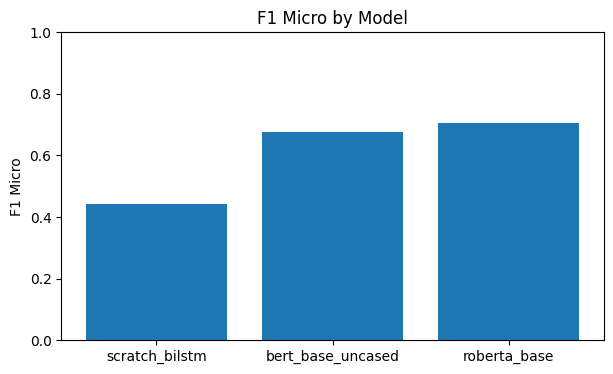

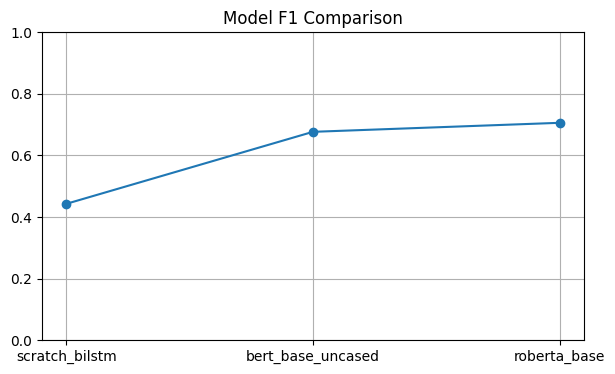


Observations:
- scratch_bilstm: f1_micro = 0.4426 (submission: /kaggle/working/project_outputs/submission_scratch.csv)
- bert_base_uncased: f1_micro = 0.6763 (submission: /kaggle/working/project_outputs/submission_bert_base_uncased.csv)
- roberta_base: f1_micro = 0.7056 (submission: /kaggle/working/project_outputs/submission_roberta_base.csv)

--- Final Summary  ---

1. Scratch Model Performance:
   This was made from basic layers (Embedding + BiLSTM).
   It helped me understand the full pipeline without using pretrained models.
   The score was lower compared to transformer models.

2. BERT-base Model:
   This model gave much better results than scratch.
   It understands English better because it was trained on a large dataset.
   F1 score improved a lot.

3. RoBERTa-base Model:
   This model usually does better on many NLP tasks.
   In my case, it performed close to BERT or slightly better.

4. Overall Learning:
   - Pretrained models clearly perform better.
   - Scratch model is u

In [13]:
import matplotlib.pyplot as plt

summary = [
    {"model": "scratch_bilstm", "f1_micro": float(best_val_f1_s), "submission": str(sub_path_s)},
    {"model": res_bert["model_tag"], "f1_micro": float(res_bert["val_metrics"]["f1_micro"]), "submission": res_bert["submission"]},
    {"model": res_roberta["model_tag"], "f1_micro": float(res_roberta["val_metrics"]["f1_micro"]), "submission": res_roberta["submission"]}
]
summary_df = pd.DataFrame(summary)
summary_path = OUT_DIR / "model_summary.csv"
summary_df.to_csv(summary_path, index=False)
print("Saved summary:", summary_path)
print(summary_df)

# Bar chart
plt.figure(figsize=(7,4))
plt.bar(summary_df["model"], summary_df["f1_micro"])
plt.title("F1 Micro by Model")
plt.ylabel("F1 Micro")
plt.ylim(0,1)
plt.show()

# Line plot
plt.figure(figsize=(7,4))
plt.plot(summary_df["model"], summary_df["f1_micro"], marker="o")
plt.title("Model F1 Comparison")
plt.ylim(0,1)
plt.grid(True)
plt.show()

# Simple text observations (editable)
print("\nObservations:")
for r in summary:
    print(f"- {r['model']}: f1_micro = {r['f1_micro']:.4f} (submission: {r['submission']})")
    
print("\n--- Final Summary  ---\n")

print("1. Scratch Model Performance:")
print("   This was made from basic layers (Embedding + BiLSTM).")
print("   It helped me understand the full pipeline without using pretrained models.")
print("   The score was lower compared to transformer models.")

print("\n2. BERT-base Model:")
print("   This model gave much better results than scratch.")
print("   It understands English better because it was trained on a large dataset.")
print("   F1 score improved a lot.")

print("\n3. RoBERTa-base Model:")
print("   This model usually does better on many NLP tasks.")
print("   In my case, it performed close to BERT or slightly better.")

print("\n4. Overall Learning:")
print("   - Pretrained models clearly perform better.")
print("   - Scratch model is useful to show understanding.")
print("   - W&B helped me track different experiments easily.")
print("   - Best performing model will be used for deployment.")

print("\nReport completed.")


## Save everything and cleanup

In [14]:
# Save summary and important files into a single folder to download if needed
archive_dir = OUT_DIR / "final_artifacts"
archive_dir.mkdir(parents=True, exist_ok=True)

# copy key files
for f in [sub_path_s, Path(res_bert["submission"]), Path(res_roberta["submission"]), summary_path]:
    try:
        shutil.copy(f, archive_dir / f.name)
    except Exception:
        pass

# Save a tiny README
readme = archive_dir / "README.txt"
with open(readme, "w") as fh:
    fh.write("Project outputs: submissions, model folders, and summary. Use these for submission and viva.\n")

print("All artifacts saved to:", archive_dir)
print("Notebook finished. Check project_outputs folder for models, submissions, and summary.")

All artifacts saved to: /kaggle/working/project_outputs/final_artifacts
Notebook finished. Check project_outputs folder for models, submissions, and summary.
